<a href="https://colab.research.google.com/github/mahdimirnami/Tensorflow-and-Keras/blob/main/fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **import liberary for fashion**

In [ ]:
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist

# **use keras for upload data**

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full , Y_train_full),(X_test_full , Y_test_full) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# divide data between **train** and **valid**

In [ ]:
X_valid , X_train = X_train_full[:5000]/255.0,X_train_full[5000:]/255.0
Y_valid , Y_train = Y_train_full[:5000] , Y_train_full[5000:]

# **category fashion**

In [ ]:
class_names = ["T_shirt/top" , "Trouser" , "Pullover" , "Dress" , "Coat","Sandal" ,"Shirt" , "Sneaker" , "Bag" , "Ankle boot"]
print(class_names[Y_train_full[0]])

Ankle boot


# Creat model **Sequential**

In [ ]:
model = keras.Sequential()
# Flattem => تبدیل هر تصویر ورودی به یک آرایه دو بعدی هستش
model.add(keras.layers.Flatten(input_shape=[28,28]))

model.add(keras.layers.Dense(300,activation='relu'))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))

print(model.summary())

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

None


# show each layers name

In [ ]:
hidden1 = model.layers[1]
print(hidden1.name)

dense_3


# Compile **Model**

In [ ]:
# sparse_categorical_crossentropy => چون برچسب ها برای هر نمونه تنها یک اندیس رده وجود دارد و رده ها انحصاری می باشند از این تابع استفاده شده است
# sgd => با کمک الگوریتم ساده کاهش گرادیان تصادفی آموزش میبینه
# accuracy => چون با یک رده بندی رو به رو هستیم از این استفاده می شود که در طی آموزش و ارزیابی به سراغ سنجه صحت برود
model.compile(loss="sparse_categorical_crossentropy"
              ,optimizer="sgd" , metrics=['accuracy'])

# **train and validtion model**

In [ ]:
# epochs => تعداد دوره های آموزش رو مشخص میکند
history = model.fit(X_train , Y_train , epochs=30 , validation_data=(X_valid,Y_valid))
print(history)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9236 - loss: 0.2118 - val_accuracy: 0.8922 - val_loss: 0.3032
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9261 - loss: 0.2077 - val_accuracy: 0.8932 - val_loss: 0.3038
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9265 - loss: 0.2050 - val_accuracy: 0.8926 - val_loss: 0.2928
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9273 - loss: 0.2022 - val_accuracy: 0.8986 - val_loss: 0.2850
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9292 - loss: 0.1988 - val_accuracy: 0.8918 - val_loss: 0.2991
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9305 - loss: 0.1968 - val_accuracy: 0.8984 - val_loss: 0.2822
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9307 - loss: 0.1935 - val_accuracy: 0.8904 - val_loss: 0.3040
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9312 - loss: 0.1901 - 

# **show dataFrame as model**

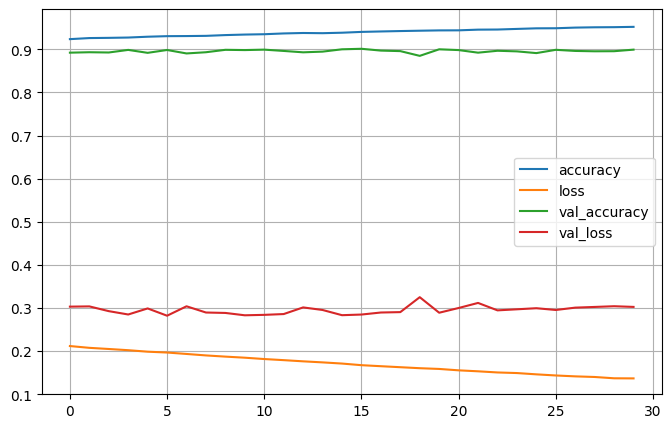

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0.1)
plt.show()

In [ ]:
print(model.evaluate(X_test_full , Y_test_full))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8575 - loss: 74.2970
[74.29704284667969, 0.8575000166893005]


# **predict model**

In [ ]:
X_new = X_test_full[:3]
Y_proba = model.predict(X_new)
Y_proba.round(2)
print(Y_proba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
import numpy as np
Y_pred_probs = model.predict(X_new)
Y_pred = np.argmax(Y_pred_probs, axis=1)
print(np.array(class_names)[Y_pred])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
['Ankle boot' 'Pullover' 'Trouser']
